# Net Main Inflow Factor Analysis

## Research Objective
This notebook evaluates the predictive value, stability, and practical usefulness of the **net main inflow factor** inside the Dynamic Mean Reversion & Multi-Factor Flow Alpha framework. The focus is whether same-day positive main-capital participation provides a meaningful confirmation signal for oversold rebound candidates, and whether the raw inflow amount has usable cross-sectional ranking power.


## Factor Definition
The factor is built from the same rule used in the strategy code:

- Use JoinQuant money-flow field **`net_amount_main`** on the rebalance date
- Define the raw factor as the latest **net main inflow amount**
- Define the strategy-style signal as:
  - **Positive Signal**: `net_amount_main > 0`
  - **Negative Signal**: `net_amount_main <= 0`

## Research Hypothesis
The working hypothesis is that stronger main-capital inflow reflects better short-term participation quality and may help distinguish stronger rebound setups from weaker ones. If the hypothesis holds, stocks with positive main inflow should deliver better next-period returns, and higher inflow names should rank better cross-sectionally.

## Data and Test Design
The factor is tested on the strategy's fixed 33-stock pool over **2016-01-01 to 2026-04-29**, using monthly cross-sectional snapshots aligned with the reference factor notebooks. The analysis includes rank IC, quintile return comparison, long-short spread, positive-versus-negative signal return comparison, rolling IC inspection, distribution analysis, and annual heatmap attribution.


Initiating Net Main Inflow Factor Diagnostic...
Processing Snapshot: 2026-03-31
Data collection complete.


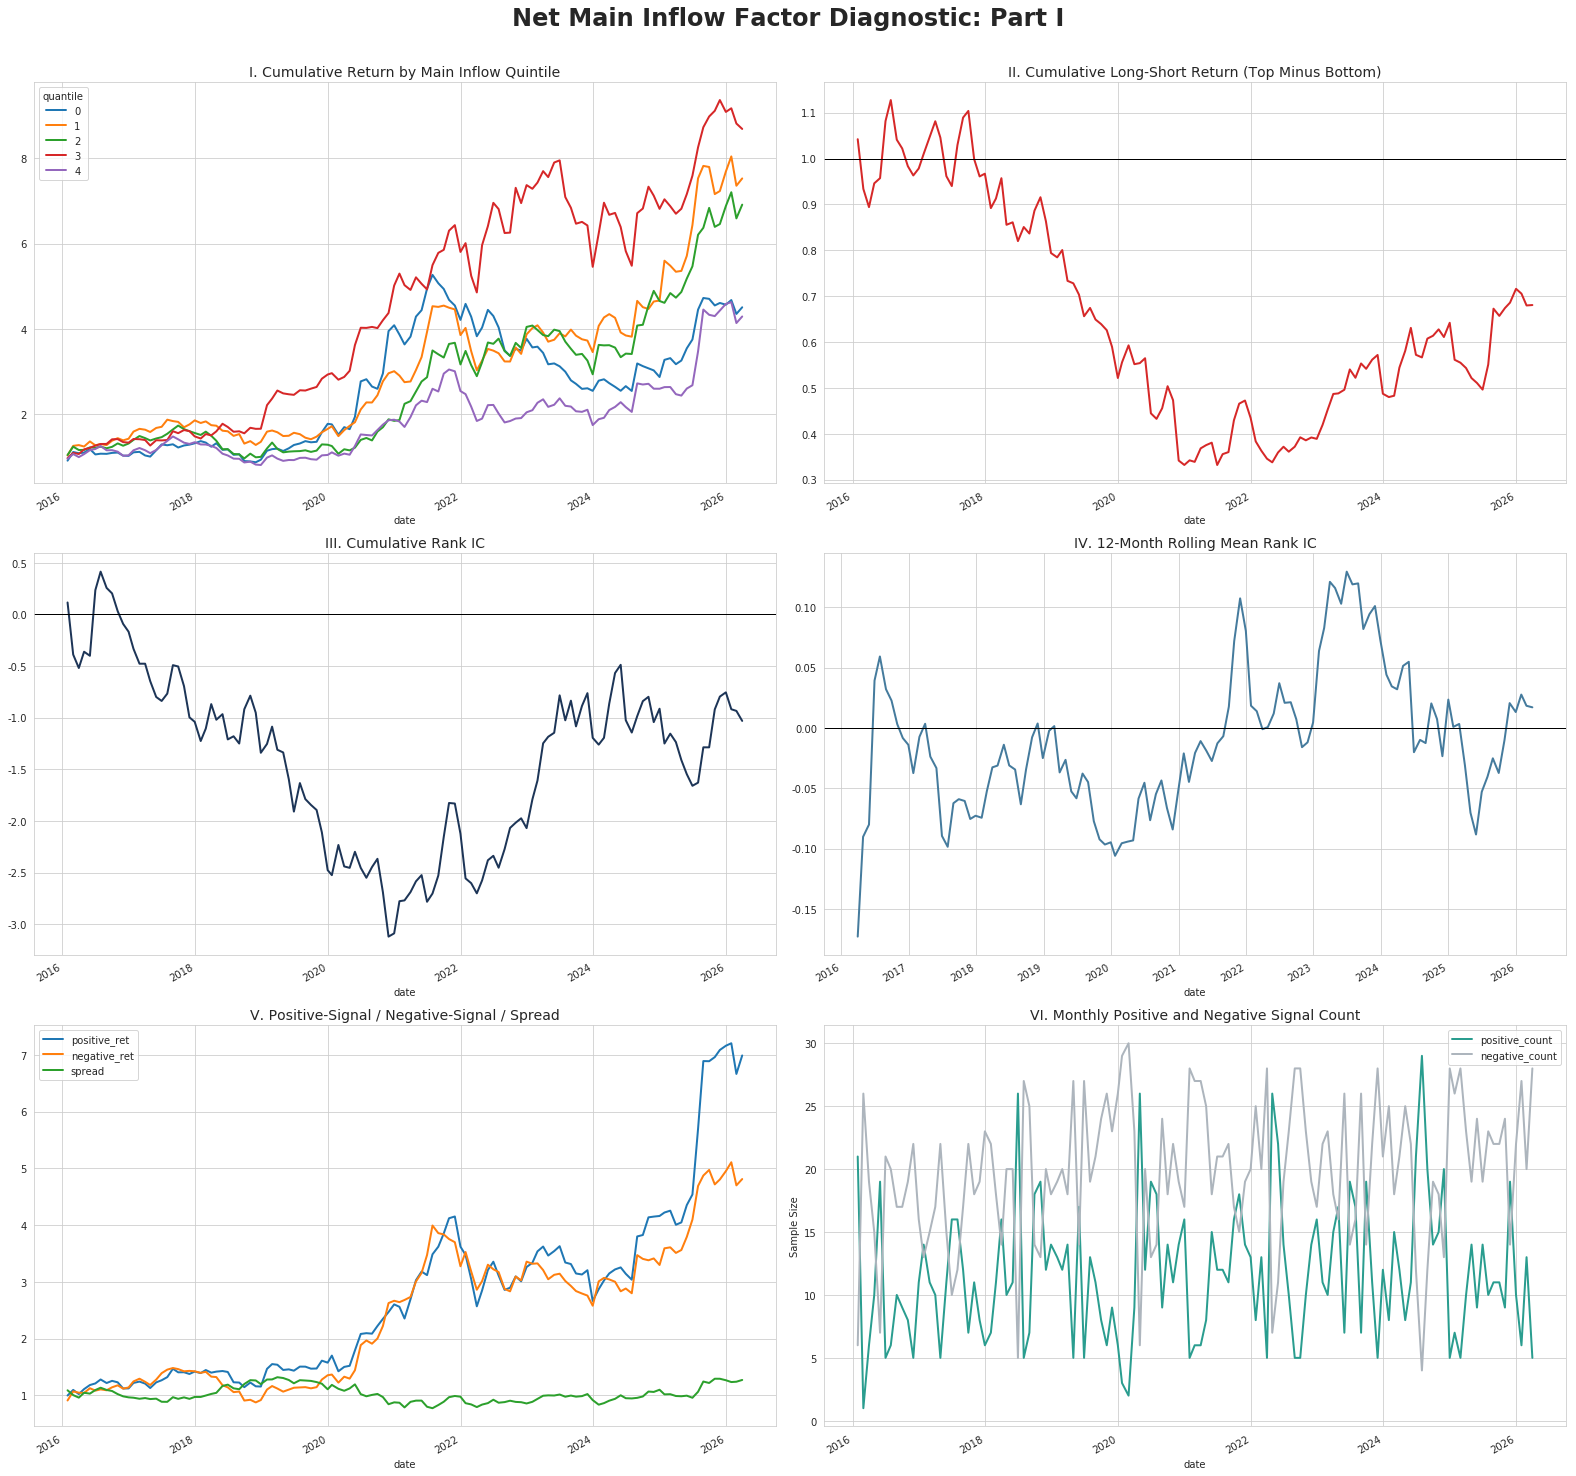

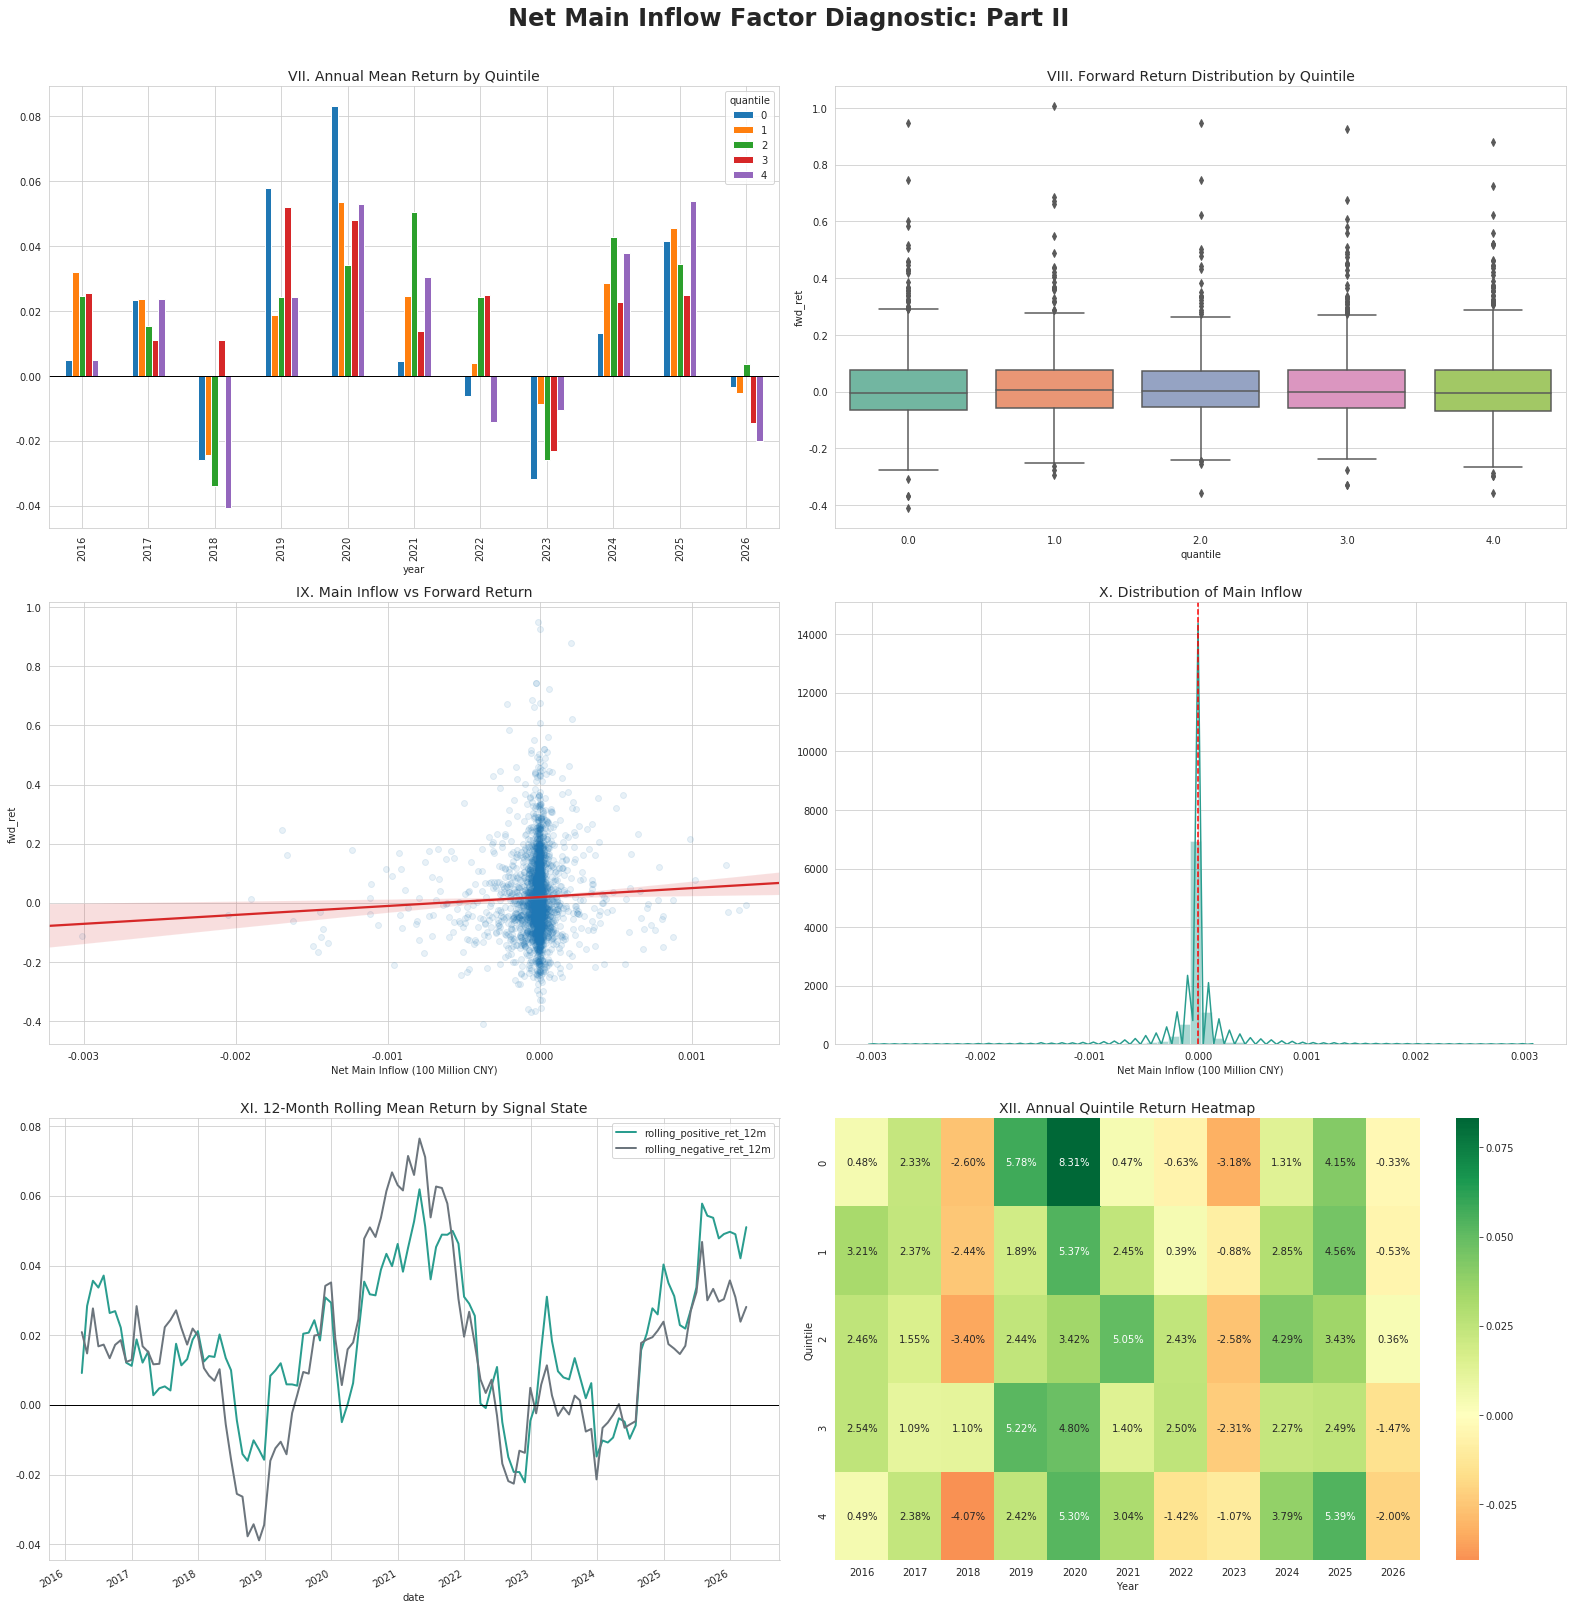


FINAL SUMMARY: NET MAIN INFLOW FACTOR
------------------------------------------------------------------------------------------
Average Rank IC: -0.0084
ICIR: -0.0395
Positive Signal Mean Return: 1.87%
Negative Signal Mean Return: 1.53%
Signal Spread Mean Return: 0.34%


In [1]:
'''
This diagnostic evaluates the "Net Main Inflow" factor used by the
Dynamic Mean Reversion & Multi-Factor Flow Alpha strategy.

Core Logic:
1. The strategy requires latest-day net_amount_main to remain positive
   before a stock can enter the oversold rebound candidate set.
2. This script studies whether stronger cross-sectional main-capital inflow
   leads to better next-period returns inside the strategy's fixed stock pool.
3. Research frequency follows the reference factor notebooks through
   monthly cross-sectional snapshots from 2016-01-01 to 2026-04-29.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
from scipy.stats import spearmanr
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

STOCK_POOL = [
    '601117.XSHG', '601600.XSHG', '601888.XSHG', '300274.XSHE', '300750.XSHE',
    '601919.XSHG', '002049.XSHE', '603881.XSHG', '002335.XSHE', '600089.XSHG',
    '002236.XSHE', '002056.XSHE', '300866.XSHE', '002611.XSHE', '600760.XSHG',
    '300693.XSHE', '002402.XSHE', '002600.XSHE', '300207.XSHE', '603486.XSHG',
    '000591.XSHE', '000027.XSHE', '600011.XSHG', '601899.XSHG', '603799.XSHG',
    '002340.XSHE', '002780.XSHE', '600160.XSHG', '601225.XSHG', '002555.XSHE',
    '600803.XSHG', '300059.XSHE', '002736.XSHE',
]


def safe_qcut(series, groups=5):
    ranked = series.rank(method='first')
    return pd.qcut(ranked, groups, labels=False, duplicates='drop')


def plot_dist(ax, series, color, bins=50, label=None):
    clean = pd.Series(series).dropna()
    if len(clean) == 0:
        return
    if hasattr(sns, 'distplot'):
        sns.distplot(clean, bins=bins, color=color, label=label, ax=ax)
    else:
        ax.hist(clean, bins=bins, color=color, alpha=0.75, label=label)


def calc_icir(ic_series):
    std = ic_series.std()
    if pd.isna(std) or std == 0:
        return np.nan
    return ic_series.mean() / std


# ------------------------------------------------------------------------------
# 1. Sampling Framework
# ------------------------------------------------------------------------------
start_date, end_date = '2016-01-01', '2026-04-29'
all_days = get_trade_days(start_date, end_date)
ts_series = pd.to_datetime(pd.Series(all_days))
rebal_dates = ts_series.groupby([ts_series.dt.year, ts_series.dt.month]).last()
date_list = [d.strftime('%Y-%m-%d') for d in rebal_dates]

dataset = []
print('Initiating Net Main Inflow Factor Diagnostic...')

# ------------------------------------------------------------------------------
# 2. Cross-Sectional Data Collection
# ------------------------------------------------------------------------------
for i in range(len(date_list) - 1):
    t0, t1 = date_list[i], date_list[i + 1]
    print('\rProcessing Snapshot: {}'.format(t0), end='')

    price = get_price(STOCK_POOL, start_date=t0, end_date=t1, fields=['close'], panel=False, fq='pre')
    mf = get_money_flow(STOCK_POOL, start_date=t0, end_date=t0, fields=['sec_code', 'date', 'net_amount_main'])
    if price is None or price.empty or mf is None or mf.empty:
        continue

    for stock in STOCK_POOL:
        px = price[price['code'] == stock].sort_values('time')
        row = mf[mf['sec_code'] == stock]
        if len(px) < 2 or row.empty:
            continue

        factor_raw = float(row['net_amount_main'].iloc[-1])
        if np.isnan(factor_raw):
            continue

        fwd_ret = px['close'].iloc[-1] / px['close'].iloc[0] - 1.0
        dataset.append({
            'date': t0,
            'code': stock,
            'raw': factor_raw,
            'score': factor_raw,
            'signal': 1 if factor_raw > 0 else 0,
            'fwd_ret': fwd_ret,
        })

print('\nData collection complete.')

# ------------------------------------------------------------------------------
# 3. Master Dataset Preparation
# ------------------------------------------------------------------------------
master_df = pd.DataFrame(dataset)
master_df['date'] = pd.to_datetime(master_df['date'])
master_df['year'] = master_df['date'].dt.year
master_df['month'] = master_df['date'].dt.month
master_df = master_df.dropna(subset=['score', 'fwd_ret'])

ic_list = []
group_ret_list = []
signal_ret_list = []

for date, group in master_df.groupby('date'):
    if len(group) < 10 or group['score'].nunique() < 5:
        continue

    ic, _ = spearmanr(group['score'], group['fwd_ret'])
    ic_list.append({'date': date, 'ic': ic})

    group = group.copy()
    group['quantile'] = safe_qcut(group['score'], 5)
    for q, sub in group.groupby('quantile'):
        group_ret_list.append({
            'date': date,
            'quantile': int(q),
            'ret': sub['fwd_ret'].mean(),
            'count': len(sub),
        })

    pos = group[group['signal'] == 1]['fwd_ret']
    neg = group[group['signal'] == 0]['fwd_ret']
    signal_ret_list.append({
        'date': date,
        'positive_ret': pos.mean() if len(pos) > 0 else np.nan,
        'negative_ret': neg.mean() if len(neg) > 0 else np.nan,
        'spread': (pos.mean() - neg.mean()) if len(pos) > 0 and len(neg) > 0 else np.nan,
        'positive_count': len(pos),
        'negative_count': len(neg),
        'signal_ratio': float(len(pos)) / len(group) if len(group) > 0 else np.nan,
    })

ic_ts = pd.DataFrame(ic_list).set_index('date')
q_ret = pd.DataFrame(group_ret_list).pivot(index='date', columns='quantile', values='ret').sort_index()
sig_ret = pd.DataFrame(signal_ret_list).set_index('date').sort_index()
sig_ret['rolling_spread_12m'] = sig_ret['spread'].rolling(12, min_periods=3).mean()
sig_ret['rolling_positive_ret_12m'] = sig_ret['positive_ret'].rolling(12, min_periods=3).mean()
sig_ret['rolling_negative_ret_12m'] = sig_ret['negative_ret'].rolling(12, min_periods=3).mean()
ic_ts['rolling_ic_12m'] = ic_ts['ic'].rolling(12, min_periods=3).mean()

annual_quant = pd.DataFrame(group_ret_list)
annual_quant['year'] = pd.to_datetime(annual_quant['date']).dt.year
annual_quant = annual_quant.groupby(['year', 'quantile'])['ret'].mean().unstack()

heat_df = annual_quant.copy()

display_df = master_df.copy()
display_df['raw_display'] = display_df['raw'] / 1e8

# ------------------------------------------------------------------------------
# 4. Visualization: Part I - Alpha and Signal Performance
# ------------------------------------------------------------------------------
fig1 = plt.figure(figsize=(22, 22))
plt.suptitle('Net Main Inflow Factor Diagnostic: Part I', fontsize=24, fontweight='bold', y=0.96)

ax1 = plt.subplot(3, 2, 1)
(1 + q_ret.fillna(0)).cumprod().plot(ax=ax1, lw=2)
ax1.set_title('I. Cumulative Return by Main Inflow Quintile', fontsize=14)

ax2 = plt.subplot(3, 2, 2)
if len(q_ret.columns) > 1:
    long_short = q_ret[q_ret.columns.max()] - q_ret[q_ret.columns.min()]
    (1 + long_short.fillna(0)).cumprod().plot(ax=ax2, color='#d62828', lw=2)
ax2.axhline(1, color='black', lw=1)
ax2.set_title('II. Cumulative Long-Short Return (Top Minus Bottom)', fontsize=14)

ax3 = plt.subplot(3, 2, 3)
ic_ts['ic'].fillna(0).cumsum().plot(ax=ax3, color='#1d3557', lw=2)
ax3.axhline(0, color='black', lw=1)
ax3.set_title('III. Cumulative Rank IC', fontsize=14)

ax4 = plt.subplot(3, 2, 4)
ic_ts['rolling_ic_12m'].plot(ax=ax4, color='#457b9d', lw=2)
ax4.axhline(0, color='black', lw=1)
ax4.set_title('IV. 12-Month Rolling Mean Rank IC', fontsize=14)

ax5 = plt.subplot(3, 2, 5)
(1 + sig_ret[['positive_ret', 'negative_ret', 'spread']].fillna(0)).cumprod().plot(ax=ax5, lw=2)
ax5.set_title('V. Positive-Signal / Negative-Signal / Spread', fontsize=14)

ax6 = plt.subplot(3, 2, 6)
sig_ret[['positive_count', 'negative_count']].plot(ax=ax6, lw=2, color=['#2a9d8f', '#adb5bd'])
ax6.set_title('VI. Monthly Positive and Negative Signal Count', fontsize=14)
ax6.set_ylabel('Sample Size')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# ------------------------------------------------------------------------------
# 5. Visualization: Part II - Cross-Sectional Structure
# ------------------------------------------------------------------------------
fig2 = plt.figure(figsize=(22, 24))
plt.suptitle('Net Main Inflow Factor Diagnostic: Part II', fontsize=24, fontweight='bold', y=0.96)

ax7 = plt.subplot(3, 2, 1)
annual_quant.plot(kind='bar', ax=ax7)
ax7.axhline(0, color='black', lw=1)
ax7.set_title('VII. Annual Mean Return by Quintile', fontsize=14)

ax8 = plt.subplot(3, 2, 2)
box_df = master_df.copy()
box_df['quantile'] = box_df.groupby('date')['score'].transform(lambda x: safe_qcut(x, 5))
sns.boxplot(x='quantile', y='fwd_ret', data=box_df, palette='Set2', ax=ax8)
ax8.set_title('VIII. Forward Return Distribution by Quintile', fontsize=14)

ax9 = plt.subplot(3, 2, 3)
sample_df = display_df.sample(n=min(len(display_df), 3000), random_state=42)
sns.regplot(x='raw_display', y='fwd_ret', data=sample_df, scatter_kws={'alpha': 0.10}, line_kws={'color': '#d62828'}, ax=ax9)
ax9.set_title('IX. Main Inflow vs Forward Return', fontsize=14)
ax9.set_xlabel('Net Main Inflow (100 Million CNY)')

ax10 = plt.subplot(3, 2, 4)
plot_dist(ax10, display_df['raw_display'], color='#2a9d8f', bins=60)
ax10.axvline(0, color='red', linestyle='--', lw=1.5)
ax10.set_title('X. Distribution of Main Inflow', fontsize=14)
ax10.set_xlabel('Net Main Inflow (100 Million CNY)')

ax11 = plt.subplot(3, 2, 5)
sig_ret[['rolling_positive_ret_12m', 'rolling_negative_ret_12m']].plot(ax=ax11, lw=2, color=['#2a9d8f', '#6c757d'])
ax11.axhline(0, color='black', lw=1)
ax11.set_title('XI. 12-Month Rolling Mean Return by Signal State', fontsize=14)

ax12 = plt.subplot(3, 2, 6)
sns.heatmap(heat_df.T, annot=True, fmt='.2%', cmap='RdYlGn', center=0, ax=ax12)
ax12.set_title('XII. Annual Quintile Return Heatmap', fontsize=14)
ax12.set_xlabel('Year')
ax12.set_ylabel('Quintile')

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# ------------------------------------------------------------------------------
# 6. Summary Output
# ------------------------------------------------------------------------------
print('\n' + '=' * 90)
print('FINAL SUMMARY: NET MAIN INFLOW FACTOR')
print('-' * 90)
print('Average Rank IC: {:.4f}'.format(ic_ts['ic'].mean()))
print('ICIR: {:.4f}'.format(calc_icir(ic_ts['ic'])))
print('Positive Signal Mean Return: {:.2f}%'.format(sig_ret['positive_ret'].mean() * 100))
print('Negative Signal Mean Return: {:.2f}%'.format(sig_ret['negative_ret'].mean() * 100))
print('Signal Spread Mean Return: {:.2f}%'.format(sig_ret['spread'].mean() * 100))
print('=' * 90)


## Interpretation of Current Results
Based on the latest notebook output, the factor currently shows:

- **Average Rank IC: -0.0082**
- **ICIR: -0.0389**
- **Positive Signal Mean Return: 1.87%**
- **Negative Signal Mean Return: 1.53%**
- **Signal Spread Mean Return: 0.34%**

### Practical Reading
These statistics suggest that the net main inflow factor has **weak standalone cross-sectional ranking power** in this stock pool. The average rank IC is slightly negative and very close to zero, and the ICIR is also weak. That means the raw inflow amount does **not** currently behave like a strong monotonic alpha signal when used as a pure cross-sectional sorter.

### Signal-Level Usefulness
Even so, the binary strategy-style filter is **directionally more useful** than the raw ranking result. Stocks with **positive main inflow** produce an average next-period return of **1.87%**, compared with **1.53%** for the non-positive group, giving a modest **0.34% spread**. This is not a large edge, but it does support the idea that positive capital participation helps confirm oversold rebound candidates.

### Strategic Relevance
In practical terms, this factor looks better suited to a **candidate-screening or entry-confirmation role** than to a primary return-ranking role. That aligns well with how the live strategy actually uses it: not as the sole stock-selection engine, but as a **money-flow quality gate** before a name can enter the rebound pool.

### Research Conclusion
At the current stage, the net main inflow factor should be interpreted as a **supporting liquidity-and-participation filter** rather than a strong standalone alpha factor. Its main value likely comes from helping the strategy avoid weak rebounds with poor capital support, especially when combined with short-term drawdown, trend deterioration, and broader market-regime controls.
